## **Data Import & Good/Bad Score Distribution**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
import importlib
import os
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120}) 

In [2]:
sys.path.append(os.path.abspath("../"))

In [3]:
import importlib
import src.metrics
importlib.reload(src.metrics)

from src.metrics import (
    plot_roc_curve, 
    plot_ks_curve, 
    
    create_decile_table, 
    plot_lift_gain_curves, 
    simulate_cutoff_scenarios, 
    plot_tradeoff_curve, 
    
    plot_quantile_calibration_curve, 
    generate_score_pd_mapping,
    
    calculate_brier_score, 
    calculate_expected_calibration_error
)

In [4]:
train_scored = pd.read_csv('../data/outputs/train_scored_final.csv')
test_scored = pd.read_csv('../data/outputs/test_scored_final.csv')

print(f"Train set: {train_scored.shape[0]:,} customers")
print(f"Test set : {test_scored.shape[0]:,} customers")

Train set: 32,599 customers
Test set : 92,254 customers


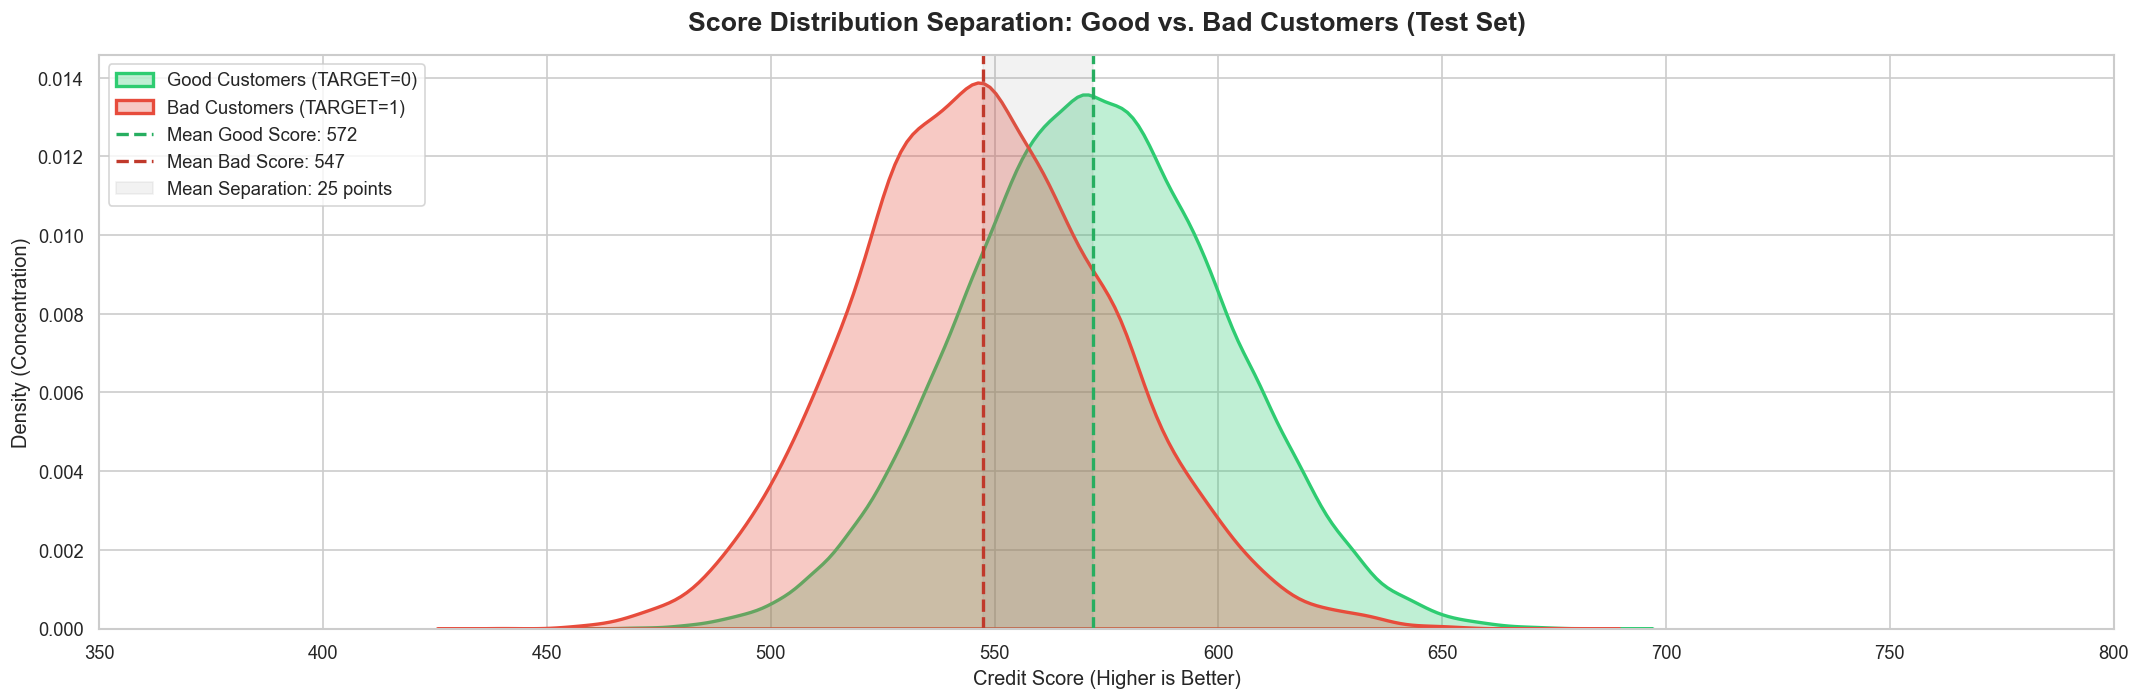

In [8]:
plt.figure(figsize=(18, 6))

# higher score = lower risk (Better customer)
# TARGET = 0 (Good), TARGET = 1 (Bad/Default)

# Plot Good Customers (Green)
sns.kdeplot(data=test_scored[test_scored['TARGET'] == 0]['SCORE'], 
            label='Good Customers (TARGET=0)', color='#2ecc71', fill=True, alpha=0.3, linewidth=2)

# Plot Bad Customers (Red)
sns.kdeplot(data=test_scored[test_scored['TARGET'] == 1]['SCORE'], 
            label='Bad Customers (TARGET=1)', color='#e74c3c', fill=True, alpha=0.3, linewidth=2)

plt.title('Score Distribution Separation: Good vs. Bad Customers (Test Set)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Credit Score (Higher is Better)', fontsize=12)
plt.ylabel('Density (Concentration)', fontsize=12)

mean_good = test_scored[test_scored['TARGET'] == 0]['SCORE'].mean()
mean_bad = test_scored[test_scored['TARGET'] == 1]['SCORE'].mean()

plt.axvline(mean_good, color='#27ae60', linestyle='--', linewidth=2, label=f'Mean Good Score: {mean_good:.0f}')
plt.axvline(mean_bad, color='#c0392b', linestyle='--', linewidth=2, label=f'Mean Bad Score: {mean_bad:.0f}')

plt.axvspan(mean_bad, mean_good, color='gray', alpha=0.1, label=f'Mean Separation: {mean_good - mean_bad:.0f} points')

plt.xlim(350, 800)
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()

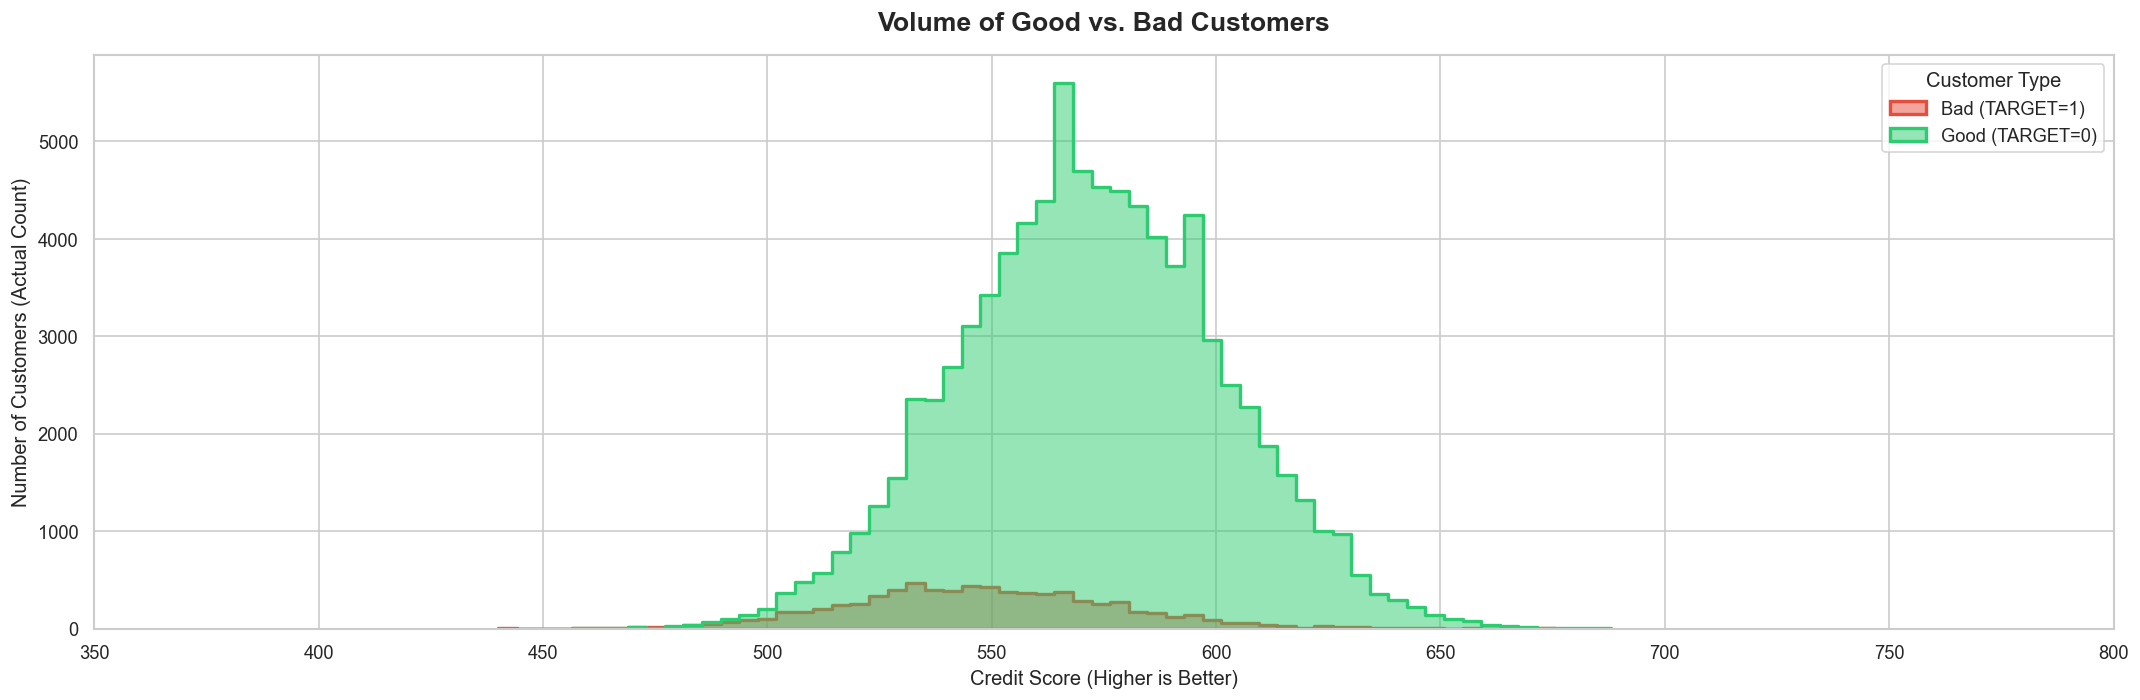

In [ ]:
plt.figure(figsize=(18, 6))

sns.histplot(data=test_scored, x='SCORE', hue='TARGET',
             palette={0: '#2ecc71', 1: '#e74c3c'},
             element='step', fill=True, alpha=0.5, 
             stat='count', bins=60, linewidth=2)

plt.title('Volume of Good vs. Bad Customers', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Credit Score (Higher is Better)', fontsize=12)
plt.ylabel('Number of Customers (Actual Count)', fontsize=12)

plt.legend(title='Customer Type', labels=['Bad (TARGET=1)', 'Good (TARGET=0)'], fontsize=11)

plt.xlim(350, 800)
plt.tight_layout()
plt.show()

## **Global Discriminatory Power (ROC & KS)**

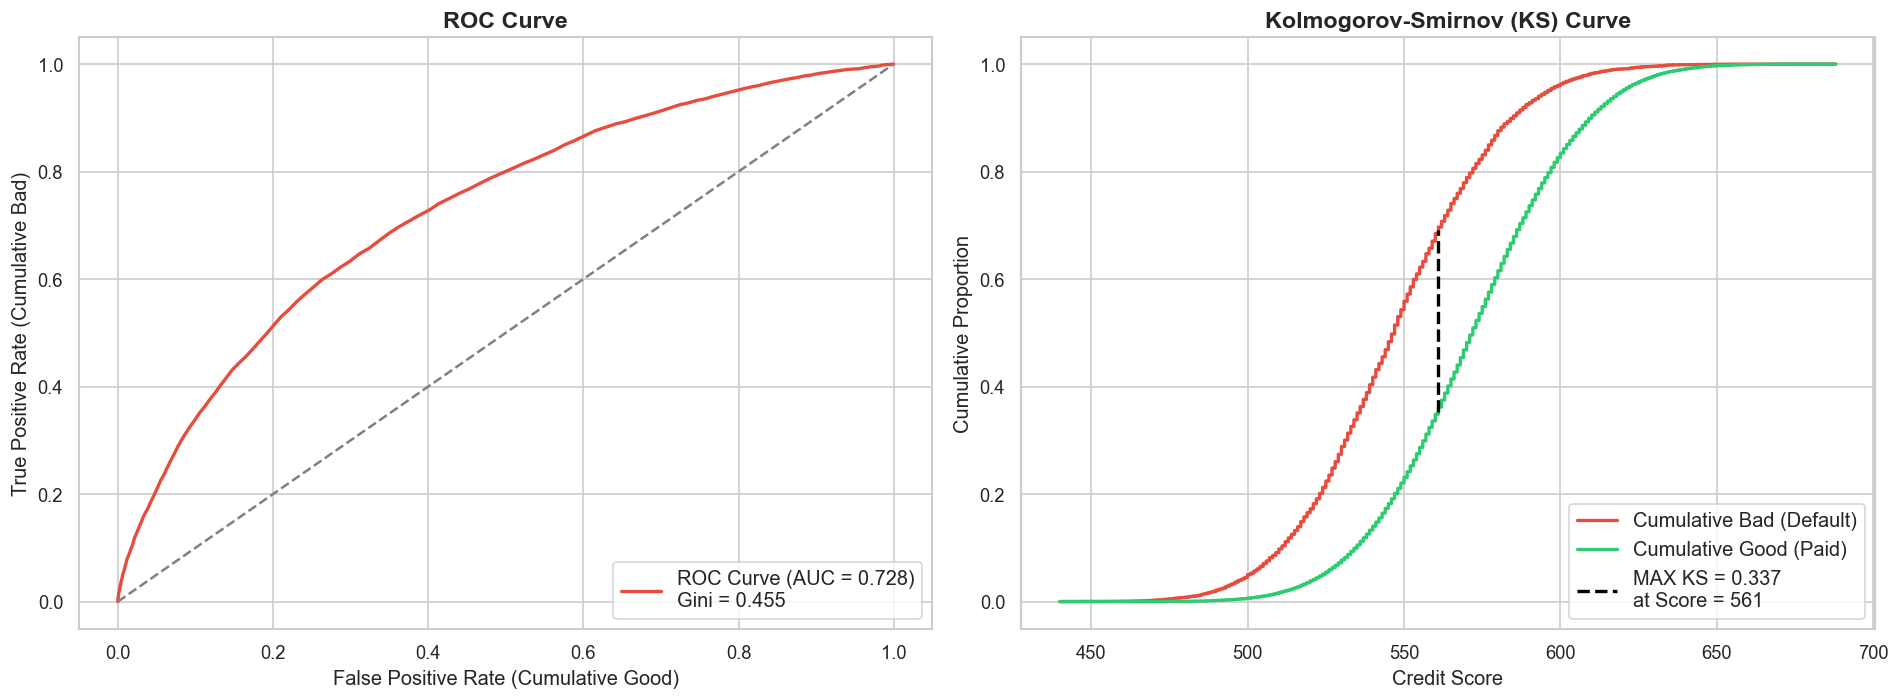

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

roc_auc, gini_score = plot_roc_curve(test_scored['TARGET'], test_scored['SCORE'], ax=axes[0])

test_ks_stat, test_ks_score = plot_ks_curve(test_scored['TARGET'], test_scored['SCORE'], ax=axes[1])

plt.tight_layout()
plt.show()

In [17]:
print(f"GINI SCORE     : {gini_score:.4f} (Ability to rank risk overall)")
print(f"KS STATISTIC   : {test_ks_stat:.4f} (Maximum separation between Good/Bad)")
print(f"OPTIMAL CUTOFF : {test_ks_score} Points (Where KS is maximized)")

GINI SCORE     : 0.4550 (Ability to rank risk overall)
KS STATISTIC   : 0.3371 (Maximum separation between Good/Bad)
OPTIMAL CUTOFF : 561 Points (Where KS is maximized)


## **Rank Ordering & Decile Analysis**

In [22]:
decile_table = create_decile_table(test_scored['TARGET'], test_scored['SCORE'])

styled_table = decile_table.style.format({
    'Min_Score': '{:.0f}',
    'Max_Score': '{:.0f}',
    'Total_Customers': '{:,.0f}',
    'Bad_Customers': '{:,.0f}',
    'Good_Customers': '{:,.0f}',
    'Bad_Rate_%': '{:.2f}%',
    '%_Cum_Bad': '{:.2f}%',
    '%_Cum_Good': '{:.2f}%',
    'KS_Stat': '{:.2f}',
    'Decile_Lift': '{:.2f}x',
    'Cum_Lift': '{:.2f}x'
}).background_gradient(subset=['Bad_Rate_%', '%_Cum_Bad', 'KS_Stat', 'Decile_Lift'], cmap='Reds')

display(styled_table)

,Decile,Min_Score,Max_Score,Total_Customers,Bad_Customers,Good_Customers,Bad_Rate_%,Cum_Bad,Cum_Good,Cum_Total_Customers,%_Cum_Bad,%_Cum_Good,KS_Stat,Decile_Lift,Cum_Lift
0,1,440,532,"9,226","2,244","6,982",24.32%,2244,6982,9226,30.13%,8.23%,21.90,3.01x,3.01x
1,2,532,545,"9,225","1,278","7,947",13.85%,3522,14929,18451,47.29%,17.60%,29.68,1.72x,2.36x
2,3,545,554,"9,225",995,"8,230",10.79%,4517,23159,27676,60.65%,27.31%,33.34,1.34x,2.02x
3,4,554,562,"9,226",743,"8,483",8.05%,5260,31642,36902,70.62%,37.31%,33.31,1.00x,1.77x
4,5,562,570,"9,225",583,"8,642",6.32%,5843,40284,46127,78.45%,47.50%,30.95,0.78x,1.57x
5,6,570,578,"9,225",495,"8,730",5.37%,6338,49014,55352,85.10%,57.80%,27.30,0.66x,1.42x
6,7,578,586,"9,226",402,"8,824",4.36%,6740,57838,64578,90.49%,68.20%,22.29,0.54x,1.29x
7,8,586,595,"9,225",312,"8,913",3.38%,7052,66751,73803,94.68%,78.71%,15.97,0.42x,1.18x
8,9,595,609,"9,225",243,"8,982",2.63%,7295,75733,83028,97.95%,89.30%,8.64,0.33x,1.09x
9,10,609,688,"9,226",153,"9,073",1.66%,7448,84806,92254,100.00%,100.00%,0.00,0.21x,1.00x


## **Cumulative Lift & Gain Charts**

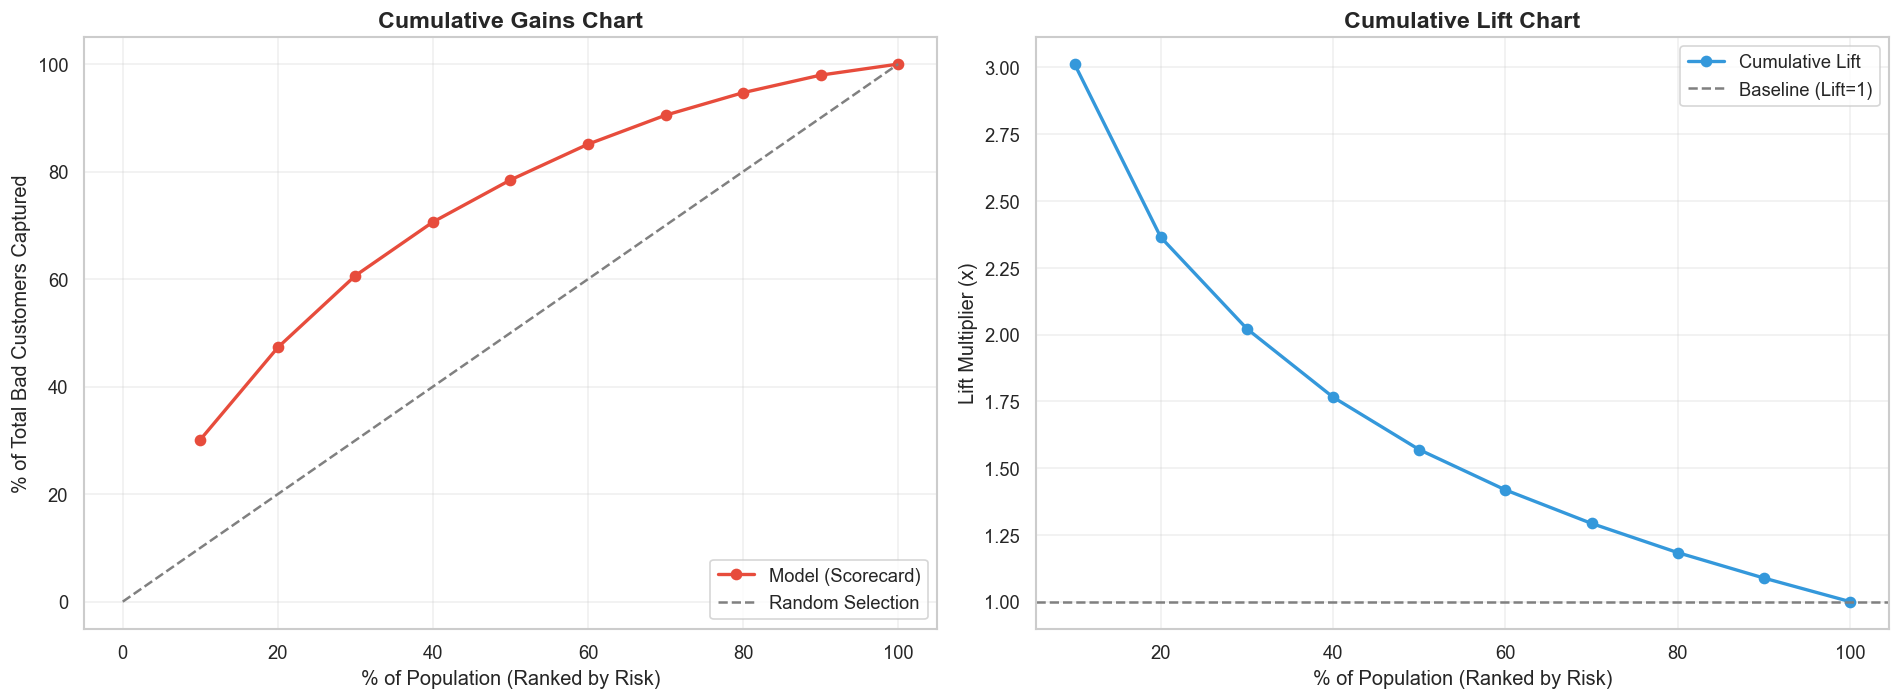

In [24]:
plot_lift_gain_curves(decile_table)

## **Cut-off Strategy & Business Decision Matrix**

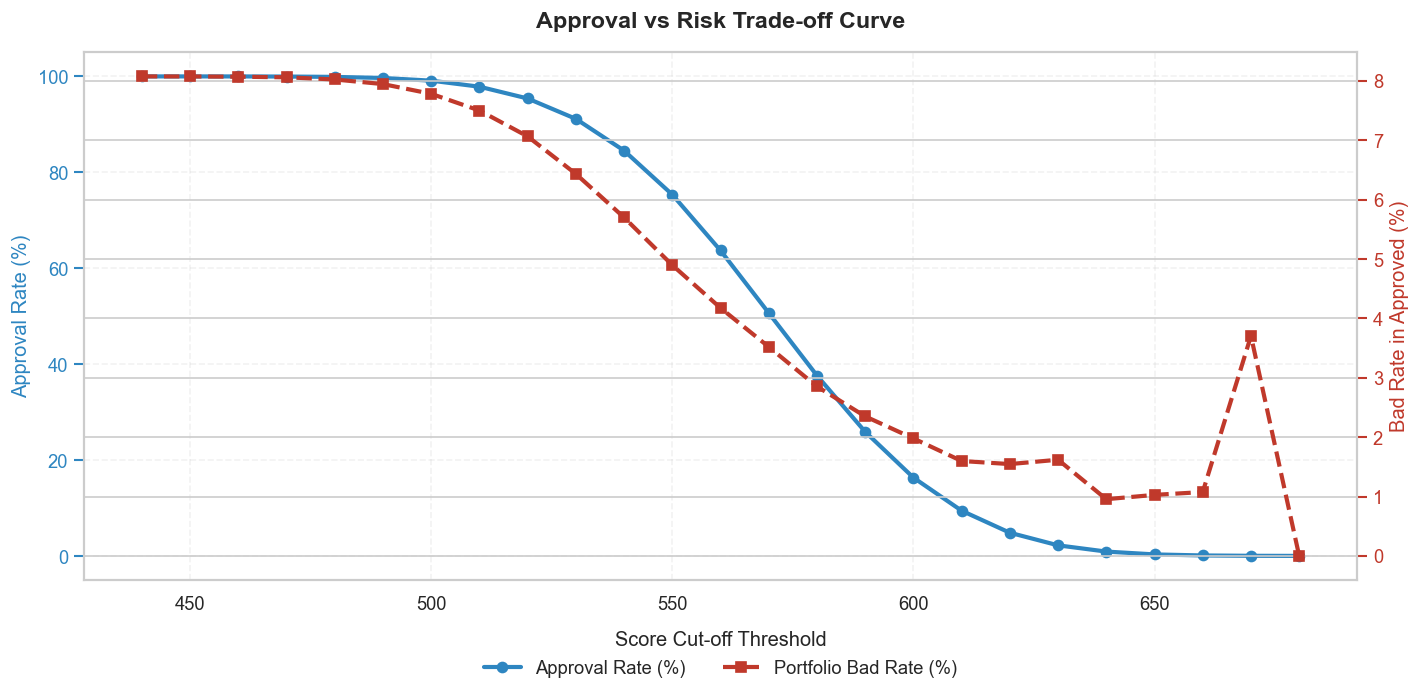

In [31]:
cutoff_matrix = simulate_cutoff_scenarios(test_scored['TARGET'], test_scored['SCORE'], step=10)

plot_tradeoff_curve(cutoff_matrix)

In [ ]:
styled_matrix = cutoff_matrix.style.format({
    'Approval_Rate_%': '{:.1f}%',
    'Portfolio_Bad_Rate_%': '{:.2f}%',
    'Bad_Capture_Rate_%': '{:.1f}%'
}).background_gradient(subset=['Approval_Rate_%'], cmap='Blues')\
  .background_gradient(subset=['Portfolio_Bad_Rate_%'], cmap='Reds', low=0, high=0.5)

display(styled_matrix)

,Cutoff,Approval_Rate_%,Portfolio_Bad_Rate_%,Bad_Capture_Rate_%
0,440,100.0%,8.07%,0.0%
1,450,100.0%,8.07%,0.0%
2,460,100.0%,8.07%,0.1%
3,470,100.0%,8.06%,0.2%
4,480,99.9%,8.02%,0.7%
5,490,99.7%,7.94%,1.9%
6,500,99.1%,7.78%,4.5%
7,510,97.9%,7.50%,9.1%
8,520,95.4%,7.06%,16.5%
9,530,91.1%,6.43%,27.4%


In [37]:
# Exact simulation row for our Optimal KS Cutoff (561)
optimal_idx = (cutoff_matrix['Cutoff'] - test_ks_score).abs().idxmin()
final_strategy = cutoff_matrix.loc[optimal_idx]

print(f"{'Model Ranking Quality (Gini)':.<45} {gini_score:.4f}")
print(f"{'Separation Power (KS Statistic)':.<45} {test_ks_stat:.4f}")

print("-" * 65)

print(f"{'RECOMMENDED SCORE CUT-OFF':.<45} {int(final_strategy['Cutoff'])} Points")
print(f"{'Expected Approval Rate':.<45} {final_strategy['Approval_Rate_%']:.1f}%")
print(f"{'Target Portfolio Bad Rate':.<45} {final_strategy['Portfolio_Bad_Rate_%']:.2f}%")
print(f"{'Bad Capture Efficiency (Safety)':.<45} {final_strategy['Bad_Capture_Rate_%']:.1f}%")

print("="*65)
print(f"By setting the bar at {int(final_strategy['Cutoff'])}, the bank achieves its maximum efficiency.")
print(f"We successfully block {final_strategy['Bad_Capture_Rate_%']:.1f}% of all potential defaults,")
print(f"keeping the portfolio loss at a very safe {final_strategy['Portfolio_Bad_Rate_%']:.2f}%.")
print("="*65)

Model Ranking Quality (Gini)................. 0.4550
Separation Power (KS Statistic).............. 0.3371
-----------------------------------------------------------------
RECOMMENDED SCORE CUT-OFF.................... 560 Points
Expected Approval Rate....................... 63.7%
Target Portfolio Bad Rate.................... 4.17%
Bad Capture Efficiency (Safety).............. 67.1%
By setting the bar at 560, the bank achieves its maximum efficiency.
We successfully block 67.1% of all potential defaults,
keeping the portfolio loss at a very safe 4.17%.


## **PD Calibration Check**

In [11]:
# Constants from Notebook 03
PDO = 20
BASE_SCORE = 600
BASE_ODDS = 50

factor = PDO / np.log(2)
offset = BASE_SCORE - (factor * np.log(BASE_ODDS))

# Calculate Logit and then Probability (PD)
# Formula: Score = Offset - Factor * Logit  =>  Logit = (Offset - Score) / Factor
logit = (offset - test_scored['SCORE']) / factor
test_scored['PROB'] = 1 / (1 + np.exp(-logit))

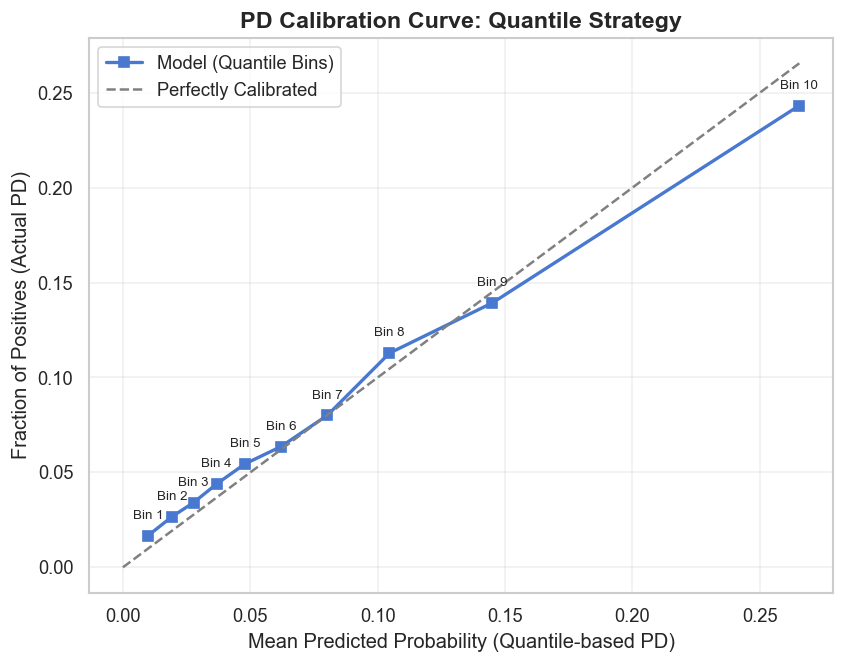

In [18]:
plot_quantile_calibration_curve(test_scored['TARGET'], test_scored['PROB'], n_bins=10)

In [14]:
bs = calculate_brier_score(test_scored['TARGET'], test_scored['PROB'])
ece = calculate_expected_calibration_error(test_scored['TARGET'], test_scored['PROB'])

print(f"Brier Score: {bs:.5f}")
print(f"ECE: {ece:.5f}")

Brier Score: 0.06965
ECE: 0.00647


## **Score to PD Mapping**

In [5]:
pd_mapping_table = generate_score_pd_mapping(test_scored)

styled_mapping = pd_mapping_table.style.background_gradient(subset=['Avg_PD_%'], cmap='RdYlGn_r') \
                                       .format({'Avg_PD_%': '{:.2f}%'})

display(styled_mapping)

,Risk_Grade,Min_Score,Max_Score,Avg_PD,Customer_Count,Avg_PD_%
0,G1,610,688,0.015977,8700,1.60%
1,G2,596,609,0.026217,9612,2.62%
2,G3,587,595,0.033577,8488,3.36%
3,G4,579,586,0.041878,9050,4.19%
4,G5,571,578,0.053581,9649,5.36%
5,G6,563,570,0.062506,9695,6.25%
6,G7,555,562,0.079377,9184,7.94%
7,G8,546,554,0.106588,8819,10.66%
8,G9,533,545,0.136305,9288,13.63%
9,G10,440,532,0.239021,9769,23.90%
